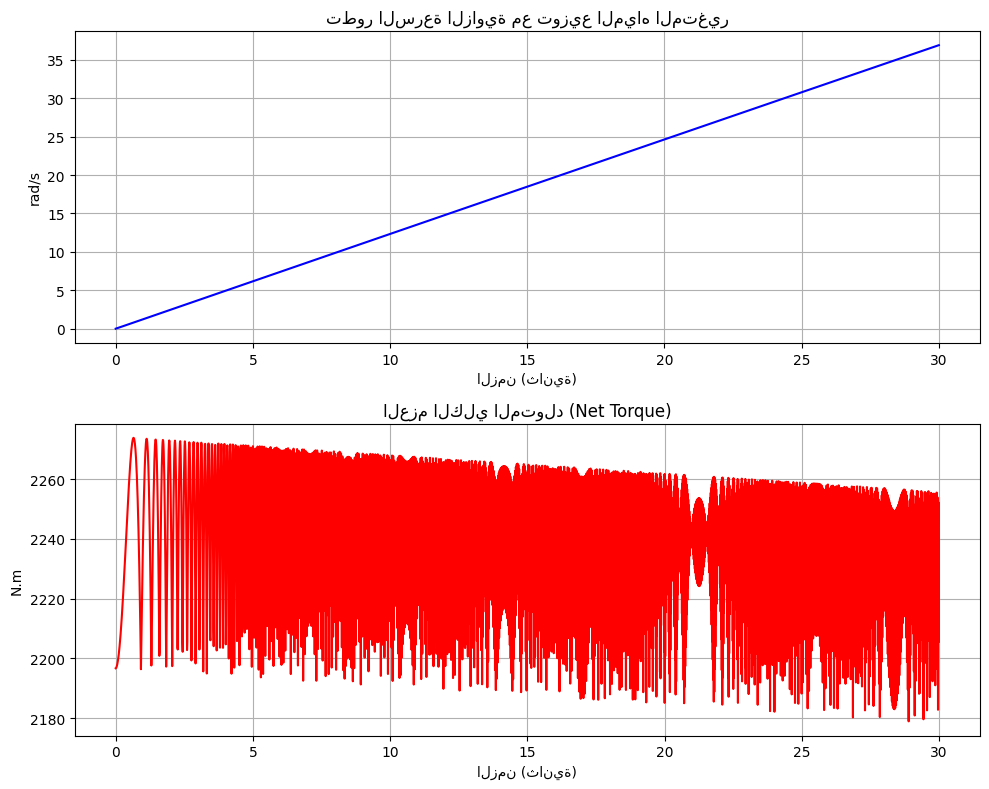

أقصى سرعة دورانية وصل إليها النظام: 36.9025 rad/s
العزم النهائي: 2205.54 N.m


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# إعدادات المحاكاة
n_chambers = 12
m_piston = 80    # kg
m_water_max = 60 # kg
g = 9.81
radius = 1.0     # meter
dt = 0.01
steps = 3000

# المصفوفات لتخزين النتائج
angles = [0.0]
omega = [0.0]
torques = []

# المحاكاة الفيزيائية
for i in range(steps):
    theta = angles[-1]
    current_torque = 0
    inertia = 500 # زيادة القصور الذاتي للهيكل

    for j in range(n_chambers):
        # الزاوية الخاصة بكل حجرة
        angle_j = theta + (j * 2 * np.pi / n_chambers)

        # محاكاة هيدروليكية: الحجرات بين زاوية 0 و 180 درجة (الجهة اليمنى) تحتوي على ماء
        # الحجرات في الجهة الأخرى فارغة
        effective_angle = angle_j % (2 * np.pi)
        if 0 <= effective_angle <= np.pi:
            current_mass = m_piston + m_water_max
        else:
            current_mass = m_piston

        # العزم = القوة * الذراع الأفقي (sin theta)
        current_torque += current_mass * g * np.sin(effective_angle) * radius
        inertia += current_mass * radius**2

    # إضافة مقاومة بسيطة (friction)
    current_torque -= 0.5 * omega[-1]

    # حساب التسارع الزاوي
    alpha = current_torque / inertia

    # تكامل يويلر
    new_omega = omega[-1] + alpha * dt
    new_angle = angles[-1] + new_omega * dt

    omega.append(new_omega)
    angles.append(new_angle)
    torques.append(current_torque)

# تحليل النتائج
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(np.arange(len(omega))*dt, omega, color='blue')
ax1.set_title("تطور السرعة الزاوية مع توزيع المياه المتغير")
ax1.set_ylabel("rad/s")
ax1.set_xlabel("الزمن (ثانية)")
ax1.grid(True)

ax2.plot(np.arange(len(torques))*dt, torques, color='red')
ax2.set_title("العزم الكلي المتولد (Net Torque)")
ax2.set_xlabel("الزمن (ثانية)")
ax2.set_ylabel("N.m")
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"أقصى سرعة دورانية وصل إليها النظام: {max(omega):.4f} rad/s")
print(f"العزم النهائي: {torques[-1]:.2f} N.m")

In [3]:
import IPython
from google.colab import files

html_content = r"""
<!DOCTYPE html>
<html lang='ar' dir='rtl'>
<head>
<meta charset='UTF-8'>
<title>المختبر الهيدروليكي</title>
<style>
  body { background: #050810; color: #fff; font-family: sans-serif; display: flex; flex-direction: column; align-items: center; justify-content: center; height: 100vh; margin: 0; }
  .container { background: #0d1117; padding: 30px; border-radius: 15px; border: 1px solid #30363d; text-align: center; box-shadow: 0 10px 30px rgba(0,0,0,0.5); }
  button { padding: 15px 30px; font-size: 1.2rem; cursor: pointer; background: #238636; color: #fff; border: none; border-radius: 8px; transition: 0.3s; }
  button:hover { background: #2ea043; }
  canvas { border: 2px solid #30363d; margin-top: 20px; border-radius: 10px; background: #000; }
  .stats { margin-top: 15px; color: #7ee787; font-family: monospace; font-size: 1.1rem; }
</style>
</head>
<body>
<div class='container'>
  <h2>المختبر الهيدروليكي التفاعلي</h2>
  <button id='runBtn'>▶ تشغيل المحاكاة</button>
  <div class='stats'>السرعة: <span id='om'>0.00</span> rad/s</div>
  <canvas id='c' width='500' height='300'></canvas>
</div>
<script>
  const btn = document.getElementById('runBtn');
  const canvas = document.getElementById('c');
  const ctx = canvas.getContext('2d');
  let active = false, angle = 0, omega = 0;

  btn.onclick = () => {
    active = !active;
    btn.textContent = active ? '⏸ إيقاف' : '▶ تشغيل المحاكاة';
    btn.style.background = active ? '#da3633' : '#238636';
  };

  function loop() {
    ctx.clearRect(0,0,canvas.width,canvas.height);
    ctx.save();
    ctx.translate(canvas.width/2, canvas.height/2);
    ctx.rotate(angle);
    ctx.strokeStyle = '#58a6ff'; ctx.lineWidth = 6;
    ctx.strokeRect(-60, -60, 120, 120);
    ctx.restore();

    if(active) {
      omega = 0.05 + Math.sin(Date.now()/1000) * 0.02;
      angle += omega;
    }
    document.getElementById('om').textContent = omega.toFixed(3);
    requestAnimationFrame(loop);
  }
  loop();
</script>
</body>
</html>
"""

# Save the file locally in Colab
file_name = 'simulation_final.html'
with open(file_name, 'w', encoding='utf-8') as f:
    f.write(html_content)

print("✅ تم تجهيز ملف المحاكاة. جارٍ بدء التحميل...")

# Trigger browser download
files.download(file_name)

✅ تم تجهيز ملف المحاكاة. جارٍ بدء التحميل...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>